# Restaurant Data Analysis Internship
This notebook contains the analysis for Levels 1 and 2 of the Restaurant Dataset analysis project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Load the dataset
file_path = '/content/Data Analysis.csv'
df = pd.read_csv(file_path)

# Basic cleaning: Remove leading/trailing spaces from column names if any
df.columns = df.columns.str.strip()

display(df.head())

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# LEVEL 1

### Task 1: Top Cuisines
In this task, we split the comma-separated cuisines, find the top 3, and calculate their prevalence.

Top 3 Cuisines:
North Indian: 3960 occurrences (41.46% of restaurants)
Chinese: 2735 occurrences (28.64% of restaurants)
Fast Food: 1986 occurrences (20.79% of restaurants)


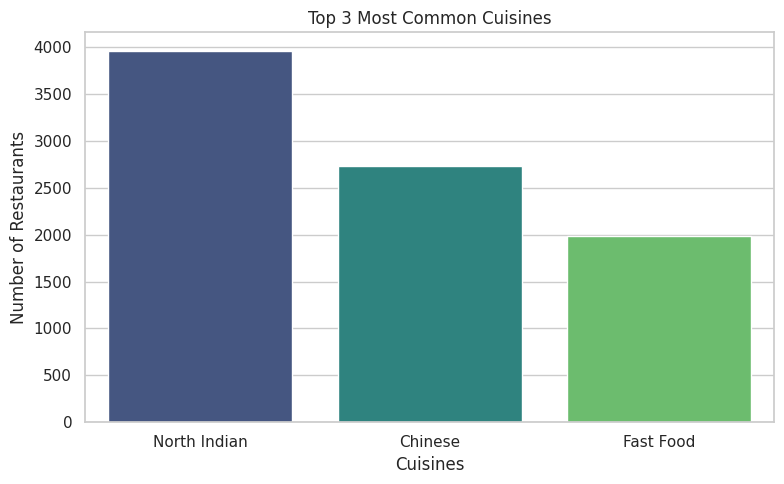

In [2]:
# Split and explode cuisines
cuisines_df = df['Cuisines'].dropna().str.split(', ')
exploded_cuisines = cuisines_df.explode()

# Find top 3 cuisines
top_3_cuisines = exploded_cuisines.value_counts().head(3)
total_restaurants = len(df)

print("Top 3 Cuisines:")
for cuisine, count in top_3_cuisines.items():
    percentage = (count / total_restaurants) * 100
    print(f"{cuisine}: {count} occurrences ({percentage:.2f}% of restaurants)")

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x=top_3_cuisines.index, y=top_3_cuisines.values, hue=top_3_cuisines.index, palette='viridis', legend=False)
plt.title('Top 3 Most Common Cuisines')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

### Task 2: City Analysis
Identifying the city with the most restaurants and the highest average ratings (excluding unrated restaurants).

City with the most restaurants: New Delhi (5473)
City with the highest average rating: Inner City (4.90)


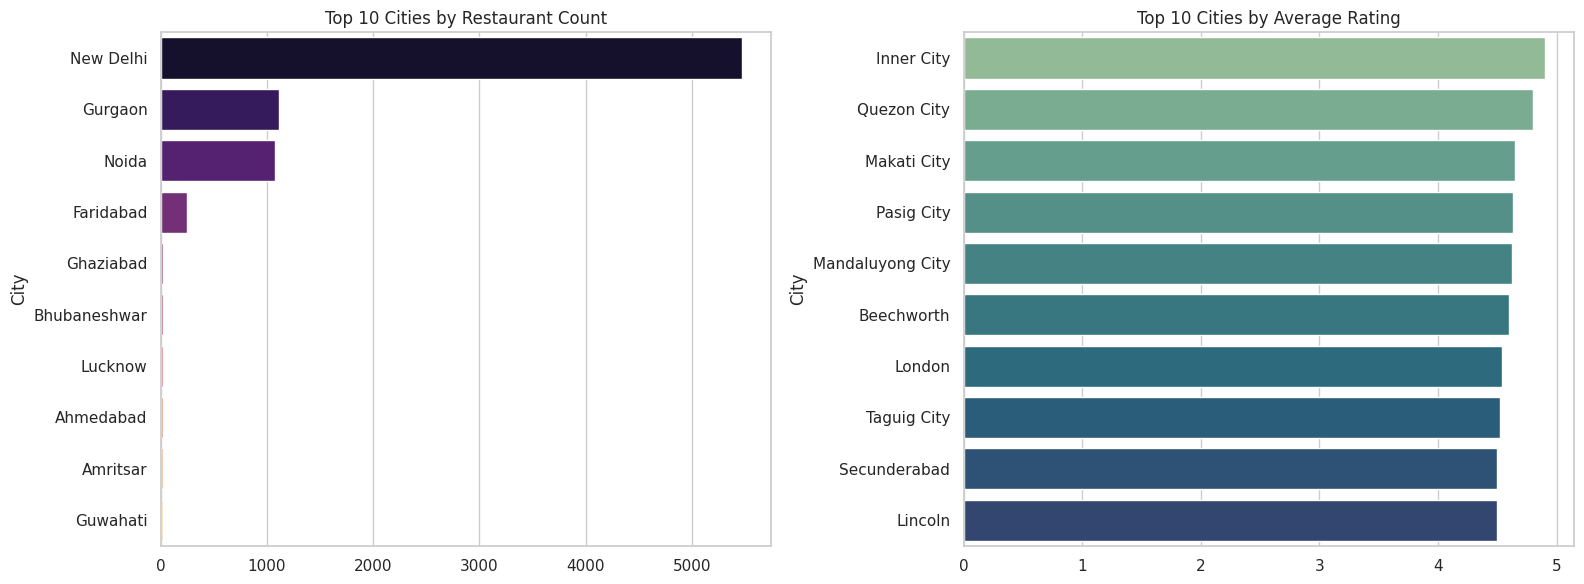

In [3]:
# City with highest number of restaurants
city_counts = df['City'].value_counts()
most_rest_city = city_counts.idxmax()

# Average rating per city (excluding 0 rating)
rated_df = df[df['Aggregate rating'] > 0]
city_ratings = rated_df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

print(f"City with the most restaurants: {most_rest_city} ({city_counts.max()})")
print(f"City with the highest average rating: {city_ratings.idxmax()} ({city_ratings.max():.2f})")

# Plotting top 10 cities by count
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=city_counts.head(10).values, y=city_counts.head(10).index, ax=axes[0], hue=city_counts.head(10).index, palette='magma', legend=False)
axes[0].set_title('Top 10 Cities by Restaurant Count')

sns.barplot(x=city_ratings.head(10).values, y=city_ratings.head(10).index, ax=axes[1], hue=city_ratings.head(10).index, palette='crest', legend=False)
axes[1].set_title('Top 10 Cities by Average Rating')

plt.tight_layout()
plt.show()

### Task 3: Price Range Distribution
Analyzing how restaurants are distributed across price ranges and how price affects rating.

Price Range Distribution:
Price Range 1: 46.53%
Price Range 2: 32.59%
Price Range 3: 14.74%
Price Range 4: 6.14%

Price range with highest average rating: 4


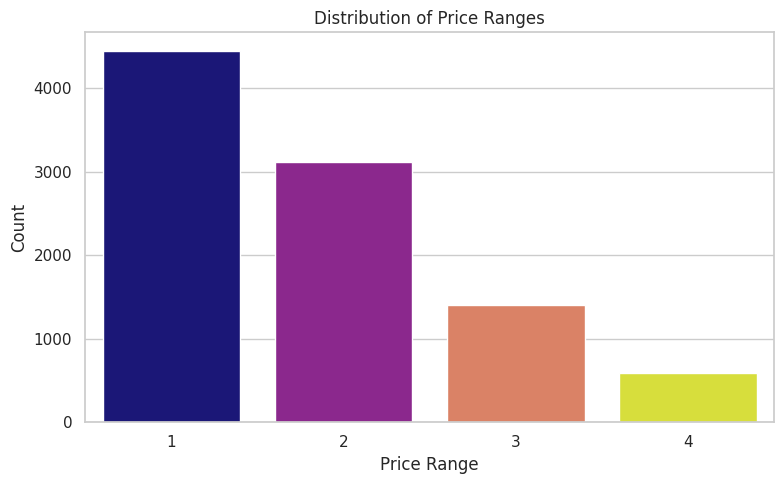

In [4]:
price_counts = df['Price range'].value_counts().sort_index()
price_pct = (price_counts / total_restaurants) * 100

# Average rating per price range
price_avg_rating = df.groupby('Price range')['Aggregate rating'].mean()

print("Price Range Distribution:")
for pr, pct in price_pct.items():
    print(f"Price Range {pr}: {pct:.2f}%")

print(f"\nPrice range with highest average rating: {price_avg_rating.idxmax()}")

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x=price_counts.index, y=price_counts.values, hue=price_counts.index, palette='plasma', legend=False)
plt.title('Distribution of Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Task 4: Online Delivery
Checking the impact of online delivery availability on restaurant ratings.

Percentage of restaurants offering online delivery: 25.66%


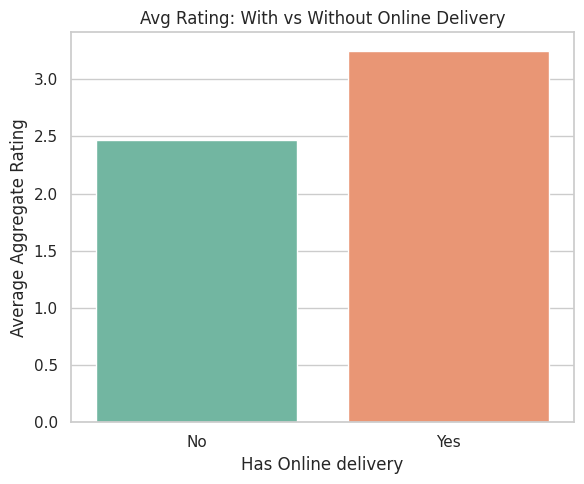

In [5]:
delivery_pct = (df['Has Online delivery'].value_counts(normalize=True)['Yes']) * 100
print(f"Percentage of restaurants offering online delivery: {delivery_pct:.2f}%")

delivery_comparison = df.groupby('Has Online delivery')['Aggregate rating'].mean()

# Plotting
plt.figure(figsize=(6, 5))
sns.barplot(x=delivery_comparison.index, y=delivery_comparison.values, hue=delivery_comparison.index, palette='Set2', legend=False)
plt.title('Avg Rating: With vs Without Online Delivery')
plt.ylabel('Average Aggregate Rating')
plt.tight_layout()
plt.show()

# LEVEL 2

### Task 1: Restaurant Ratings
Analyzing the distribution of ratings and handling unrated data points.

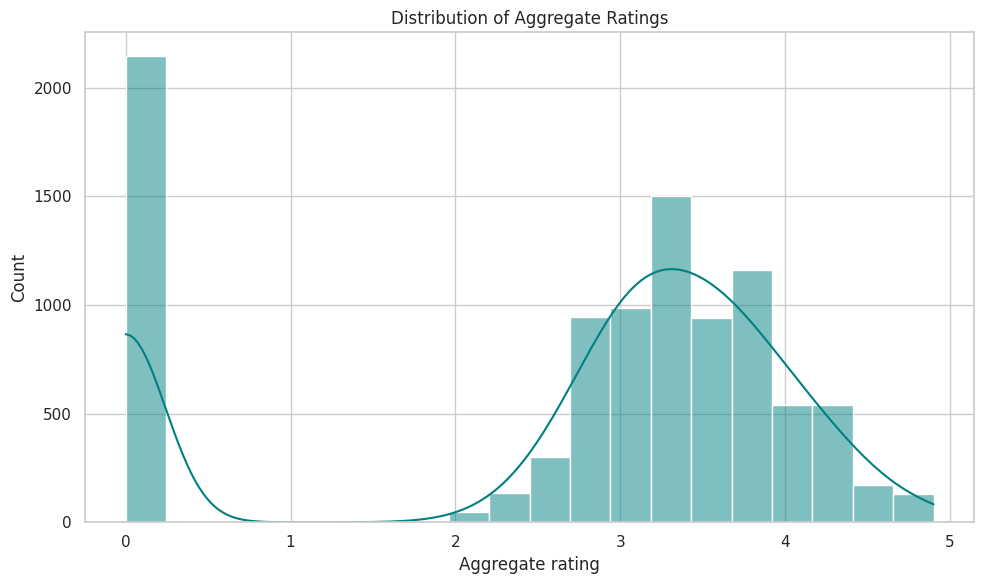

Most common rating range (rated): (3.0, 3.5]
Average number of votes per restaurant: 156.91


In [6]:
# Note: 0.0 ratings are unrated restaurants. We'll show the distribution of all, then focus on rated ones.
plt.figure(figsize=(10, 6))
sns.histplot(df['Aggregate rating'], bins=20, kde=True, color='teal')
plt.title('Distribution of Aggregate Ratings')
plt.tight_layout()
plt.show()

# Most common rating range (excluding 0)
rated_only = df[df['Aggregate rating'] > 0]['Aggregate rating']
common_range = pd.cut(rated_only, bins=[0, 1, 2, 3, 3.5, 4, 4.5, 5]).value_counts().idxmax()

avg_votes = df['Votes'].mean()

print(f"Most common rating range (rated): {common_range}")
print(f"Average number of votes per restaurant: {avg_votes:.2f}")

### Task 2: Cuisine Combinations
Identifying the most popular groups of cuisines offered together.

,Count,Avg Rating
Cuisines,,
North Indian,936,3.181504
"North Indian, Chinese",511,3.117128
Chinese,354,3.227232
Fast Food,354,3.289035
"North Indian, Mughlai",334,3.281633
Cafe,299,3.430159
Bakery,218,3.226923
"North Indian, Mughlai, Chinese",197,3.085366
"Bakery, Desserts",170,3.396552


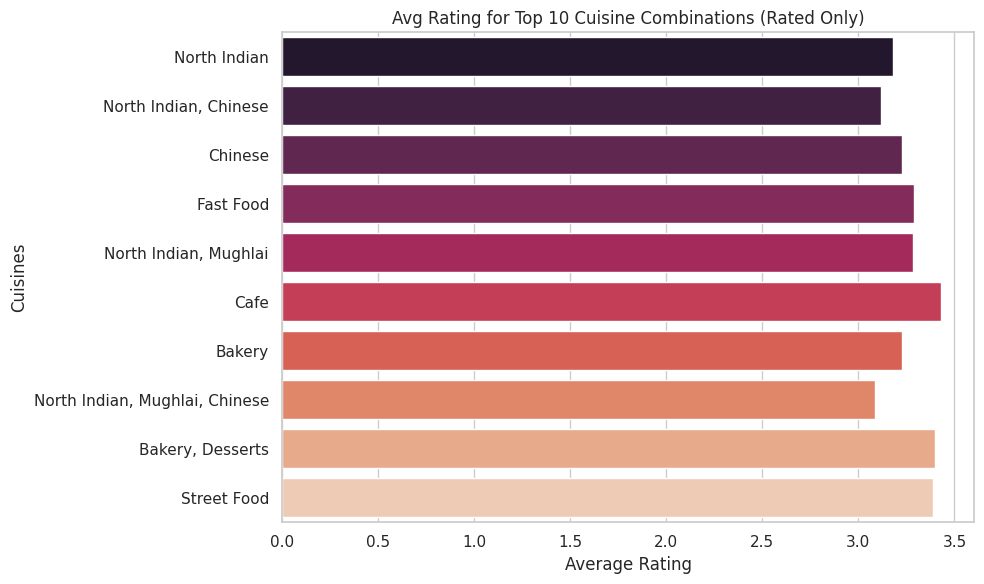

In [7]:
# Filter for rated restaurants to ensure accurate average calculations
rated_df = df[df['Aggregate rating'] > 0]

top_combos = df['Cuisines'].value_counts().head(10)
combo_ratings = rated_df[rated_df['Cuisines'].isin(top_combos.index)].groupby('Cuisines')['Aggregate rating'].mean().reindex(top_combos.index)

# Display as table
combo_df = pd.DataFrame({'Count': top_combos, 'Avg Rating': combo_ratings})
display(combo_df)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=combo_ratings.values, y=combo_ratings.index, hue=combo_ratings.index, palette='rocket', legend=False)
plt.title('Avg Rating for Top 10 Cuisine Combinations (Rated Only)')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

### Task 3: Geographic Analysis
Mapping the location of restaurants globally and specifically in New Delhi.

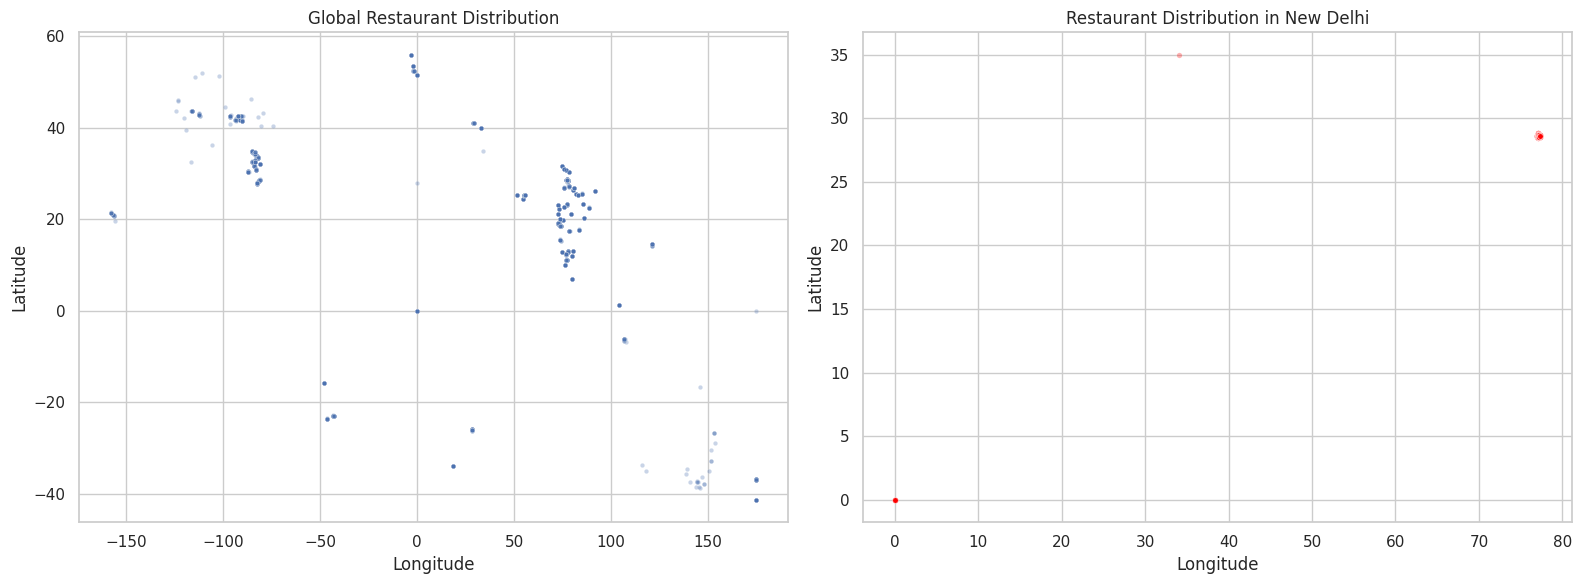

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Global Plot
sns.scatterplot(data=df, x='Longitude', y='Latitude', alpha=0.3, s=10, ax=axes[0])
axes[0].set_title('Global Restaurant Distribution')

# New Delhi Plot
delhi_df = df[df['City'] == 'New Delhi']
sns.scatterplot(data=delhi_df, x='Longitude', y='Latitude', alpha=0.3, s=15, color='red', ax=axes[1])
axes[1].set_title('Restaurant Distribution in New Delhi')

plt.tight_layout()
plt.show()

Geographic Observation: The global plot shows significant clusters in India, specifically North India (Delhi/NCR), and scattered locations across other continents. The New Delhi plot shows a very dense, centralized cluster indicating a high concentration of urban dining.

### Task 4: Restaurant Chains
Analyzing multi-outlet restaurant brands.

,Aggregate rating,Votes,Outlets
Restaurant Name,,,
Cafe Coffee Day,2.997015,36.000000,83
Domino's Pizza,2.925676,89.689189,79
Subway,3.003279,100.360656,63
Green Chick Chop,3.097727,21.659091,51
McDonald's,3.410638,112.553191,48
Keventers,3.365517,43.206897,34
Pizza Hut,3.434483,171.068966,30
Giani,3.250000,35.375000,29
Baskin Robbins,3.256250,25.875000,28


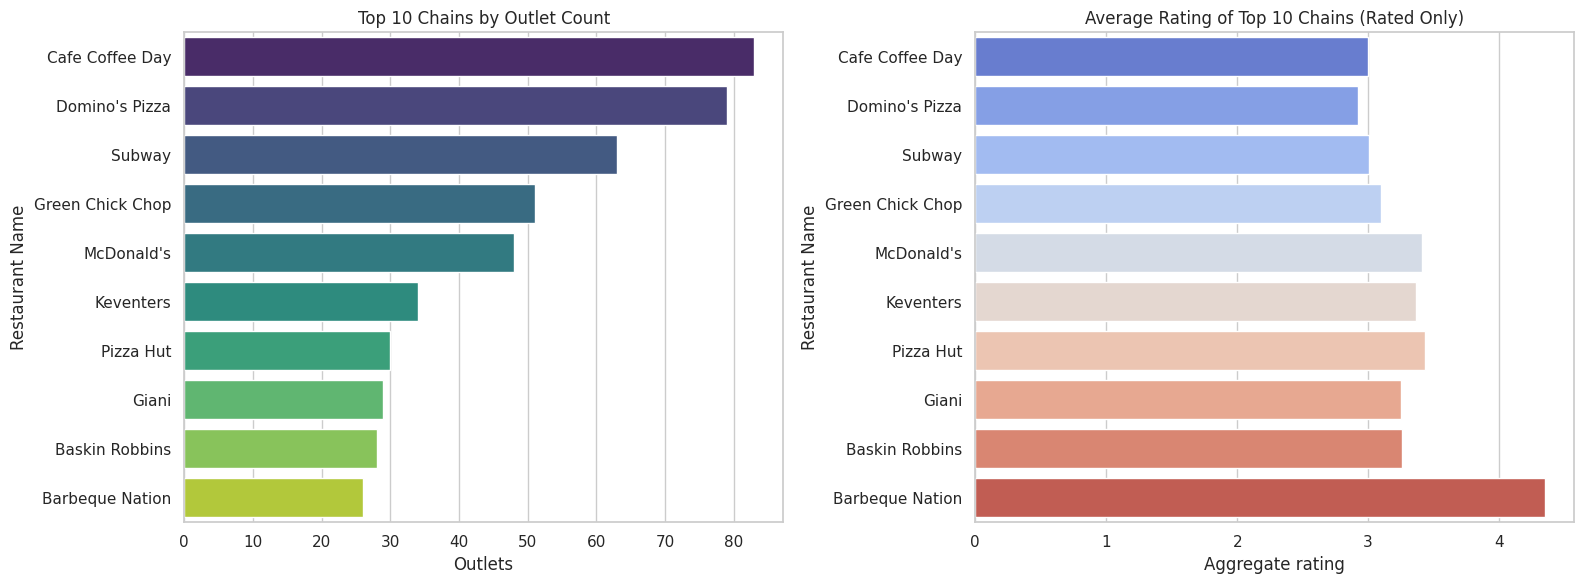

In [9]:
# Filter for rated restaurants for chain analysis
rated_df = df[df['Aggregate rating'] > 0]

chain_counts = df['Restaurant Name'].value_counts()
top_10_chains = chain_counts[chain_counts > 1].head(10)

chain_stats = rated_df[rated_df['Restaurant Name'].isin(top_10_chains.index)].groupby('Restaurant Name').agg({
    'Aggregate rating': 'mean',
    'Votes': 'mean'
}).reindex(top_10_chains.index)

# Add outlet counts from original df
chain_stats['Outlets'] = top_10_chains

display(chain_stats)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=chain_stats['Outlets'], y=chain_stats.index, ax=axes[0], hue=chain_stats.index, palette='viridis', legend=False)
axes[0].set_title('Top 10 Chains by Outlet Count')

sns.barplot(x=chain_stats['Aggregate rating'], y=chain_stats.index, ax=axes[1], hue=chain_stats.index, palette='coolwarm', legend=False)
axes[1].set_title('Average Rating of Top 10 Chains (Rated Only)')

plt.tight_layout()
plt.show()

# Key Findings Summary
- **Cuisine Popularity**: North Indian, Chinese, and Fast Food are the most dominant cuisines in the dataset.
- **Geographic Density**: New Delhi has the highest concentration of restaurants by a significant margin.
- **Rating Disparity**: Restaurants that offer **Online Delivery** tend to have a higher average aggregate rating compared to those that do not.
- **Price vs Rating**: Higher price range categories (3 and 4) generally correlate with higher average ratings.
- **Common Ratings**: Excluding unrated restaurants (0.0), the most frequent ratings fall between 3.0 and 4.0.
- **Chains**: Several popular brands have numerous outlets (chains), but their average ratings vary, suggesting inconsistent quality across locations.
- **Global Spread**: The dataset is heavily skewed towards Indian cities, particularly in the NCR region.